In [7]:
import numpy as np

X = np.array([
    [2.0, 3.0],
    [3.0, 3.0],
    [2.0, 4.0],
    [0.0, 0.0],
    [1.0, 0.0],
    [0.0, 1.0]
])

y = np.array([1, 1, 1, -1, -1, -1])

alpha = 0.001
Lambda = 0.01
iterations = 1000

samples,features = X.shape
w = np.zeros(features)
b = 0

for _ in range(iterations):
    for idx,x_i in enumerate(X):
        condition = y[idx]*(np.dot(w,x_i) - b)>=1
        if condition:
            w-= alpha*(2*Lambda*w)
        else:
            w -= alpha * (2 * Lambda * w - np.dot(x_i, y[idx]))
            b -= alpha*y[idx]

print(w)
print(b)

[0.45318534 0.53595548]
1.504999999999945


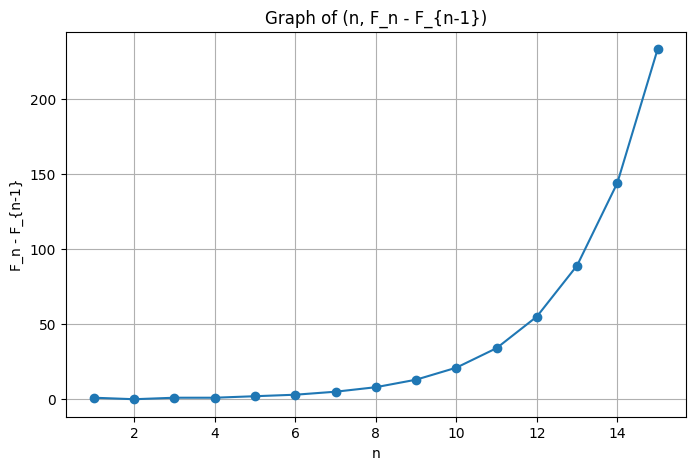

In [1]:
import matplotlib.pyplot as plt

def fibonacci(n):
    fib = [0, 1]
    for i in range(2, n + 1):
        fib.append(fib[i - 1] + fib[i - 2])
    return fib

# Number of points to plot
N = 15

# Generate Fibonacci numbers
fib = fibonacci(N)

# Prepare data for plotting (n, F_n - F_{n-1})
x = []
y = []

for n in range(1, N + 1):
    x.append(n)
    y.append(fib[n] - fib[n - 1])

# Plot the graph
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o')
plt.title("Graph of (n, F_n - F_{n-1})")
plt.xlabel("n")
plt.ylabel("F_n - F_{n-1}")
plt.grid(True)
plt.show()

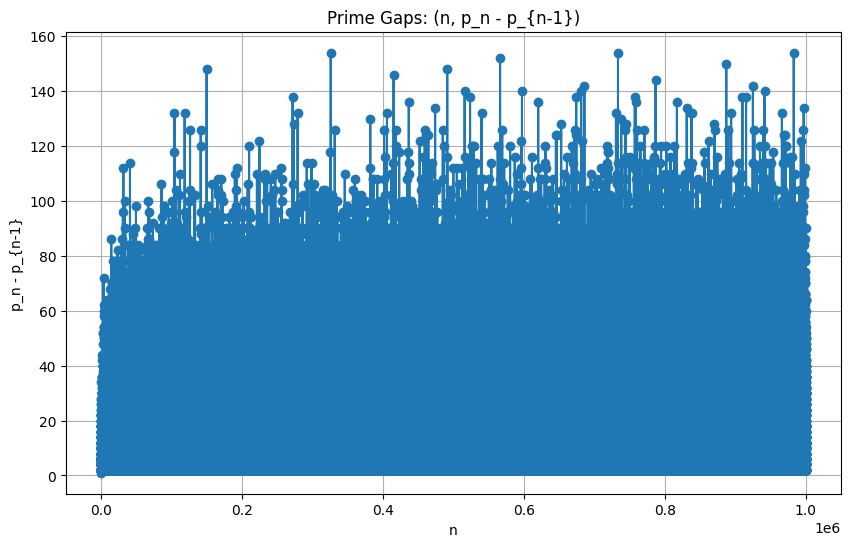

In [6]:
import matplotlib.pyplot as plt
from sympy import primerange

def first_n_primes(n):
    primes = []
    candidate = 2
    while len(primes) < n:
        is_prime = True
        for p in primes:
            if p * p > candidate:
                break
            if candidate % p == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(candidate)
        candidate += 1
    return primes

def plot_prime_gaps(N):
    primes = first_n_primes(N)
    
    gaps = []
    indices = []
    
    for i in range(1, len(primes)):
        gaps.append(primes[i] - primes[i - 1])
        indices.append(i + 1)  # corresponds to p_n
    
    plt.figure(figsize=(10, 6))
    plt.plot(indices, gaps, marker='o', linestyle='-')
    plt.xlabel("n")
    plt.ylabel("p_n - p_{n-1}")
    plt.title("Prime Gaps: (n, p_n - p_{n-1})")
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    N = 1000000  # Change this value to plot more primes
    plot_prime_gaps(N)

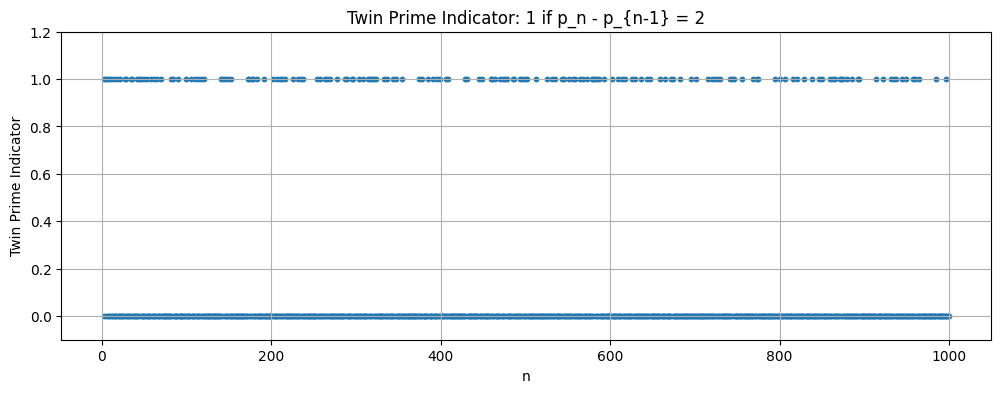

In [7]:
import matplotlib.pyplot as plt

def first_n_primes(n):
    primes = []
    candidate = 2
    while len(primes) < n:
        is_prime = True
        for p in primes:
            if p * p > candidate:
                break
            if candidate % p == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(candidate)
        candidate += 1
    return primes

def twin_prime_indicator(N):
    primes = first_n_primes(N)
    
    indices = []
    indicator = []
    
    for i in range(1, len(primes)):
        indices.append(i + 1)  # corresponds to p_n
        if primes[i] - primes[i-1] == 2:
            indicator.append(1)
        else:
            indicator.append(0)

    plt.figure(figsize=(12, 4))
    plt.scatter(indices, indicator, s=10)
    plt.xlabel("n")
    plt.ylabel("Twin Prime Indicator")
    plt.title("Twin Prime Indicator: 1 if p_n - p_{n-1} = 2")
    plt.ylim(-0.1, 1.2)
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    N = 1000  # increase to see thinning effect
    twin_prime_indicator(N)

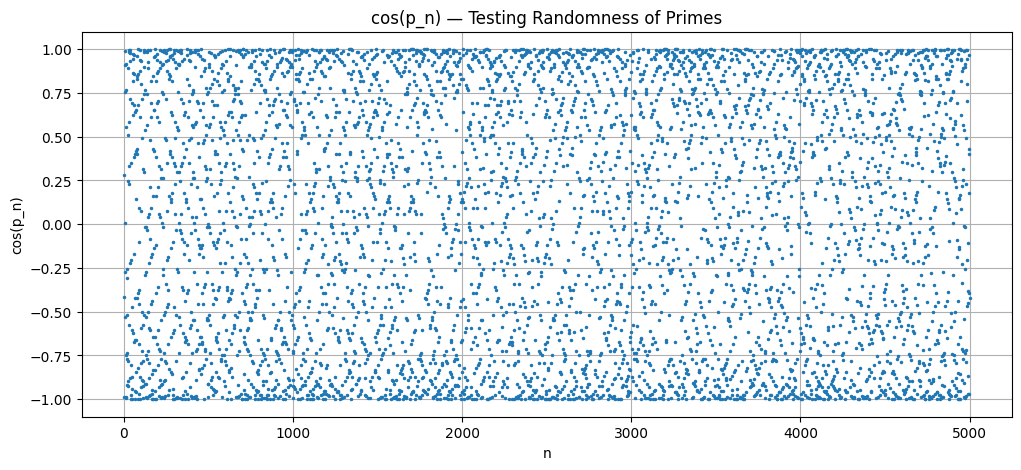

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def first_n_primes(n):
    primes = []
    candidate = 2
    while len(primes) < n:
        is_prime = True
        for p in primes:
            if p * p > candidate:
                break
            if candidate % p == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(candidate)
        candidate += 1
    return primes

def plot_cos_primes(N):
    primes = first_n_primes(N)
    values = np.cos(primes)

    plt.figure(figsize=(12,5))
    plt.plot(range(1, N+1), values, '.', markersize=3)
    plt.xlabel("n")
    plt.ylabel("cos(p_n)")
    plt.title("cos(p_n) — Testing Randomness of Primes")
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    N = 5000
    plot_cos_primes(N)

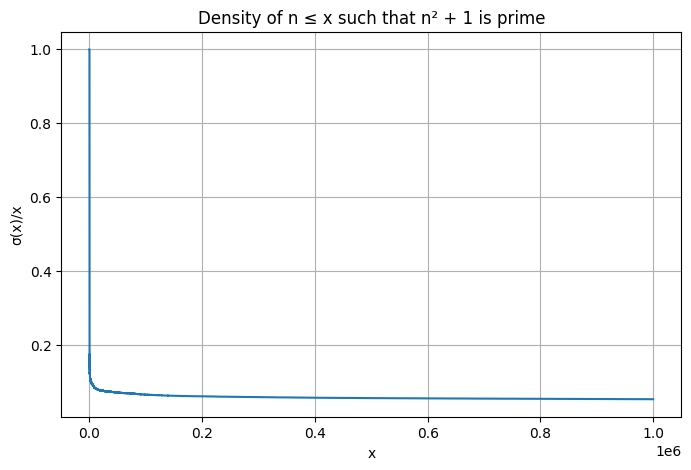

In [5]:
import sympy as sp
import matplotlib.pyplot as plt
import math

def sigma_values(x_max):
    count = 0
    xs = []
    sigmas = []
    
    for n in range(1, x_max + 1):
        if sp.isprime(n*n + 1):
            count += 1
        xs.append(n)
        sigmas.append(count)
    
    return xs, sigmas

x_max = 1_000_000   # start smaller; 10^7 is very slow
xs, sigmas = sigma_values(x_max)

# ---- Plot σ(x)/x ----
ratios = [sigmas[i] / xs[i] for i in range(len(xs))]

plt.figure(figsize=(8,5))
plt.plot(xs, ratios)
plt.xlabel("x")
plt.ylabel("σ(x)/x")
plt.title("Density of n ≤ x such that n² + 1 is prime")
plt.grid(True)
plt.show()